# Movie Review Sentiment Analysis

A binary sentiment classifier for IMDB movie reviews built with traditional machine learning and TF-IDF text features. The dataset contains 50,000 labeled reviews — 25,000 positive and 25,000 negative — making it one of the most commonly used benchmarks for NLP classification.

**Models:** Logistic Regression, Multinomial Naive Bayes, Linear SVM, Random Forest

**Dataset:** [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

## Table of Contents

1. [Setup](#1-setup)
2. [Load Dataset](#2-load-dataset)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Text Preprocessing](#4-text-preprocessing)
5. [Feature Extraction — TF-IDF](#5-feature-extraction--tfidf)
6. [Model Training and Evaluation](#6-model-training-and-evaluation)
7. [Model Comparison](#7-model-comparison)
8. [Error Analysis](#8-error-analysis)
9. [Save Best Model](#9-save-best-model)
10. [Custom Review Testing](#10-custom-review-testing)

## 1. Setup

All required libraries are imported here.

In [22]:
# data handling
import numpy as np
import pandas as pd
# visualization
import matplotlib.pyplot as plt
import seaborn as sns
# utilities
import re
import os
import json
import warnings
import joblib
from collections import Counter
from time import time

# NLP
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

print('All libraries loaded.')

All libraries loaded.


## 2. Load Dataset

The CSV is loaded and checked for shape, missing values, and duplicate rows. The file path is auto-detected so the notebook runs on both Kaggle and locally.

In [23]:
KAGGLE_PATH = '/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'
LOCAL_PATH  = 'dataset/IMDB Dataset.csv'

# auto-detect whether the notebook is running on Kaggle or locally
DATA_PATH = KAGGLE_PATH if os.path.exists(KAGGLE_PATH) else LOCAL_PATH

df = pd.read_csv(DATA_PATH)

print(f'Shape       : {df.shape}')
print(f'Columns     : {df.columns.tolist()}')
print(f'Missing vals: {df.isnull().sum().to_dict()}')
print(f'Duplicates  : {df.duplicated().sum()}')
df.head(3)

Shape       : (50000, 2)
Columns     : ['review', 'sentiment']
Missing vals: {'review': 0, 'sentiment': 0}
Duplicates  : 418


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


## 3. Exploratory Data Analysis

A look at the class balance, review lengths, and the most frequent words in positive and negative reviews before any modeling begins.

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Balance: {'positive': 50.0, 'negative': 50.0}


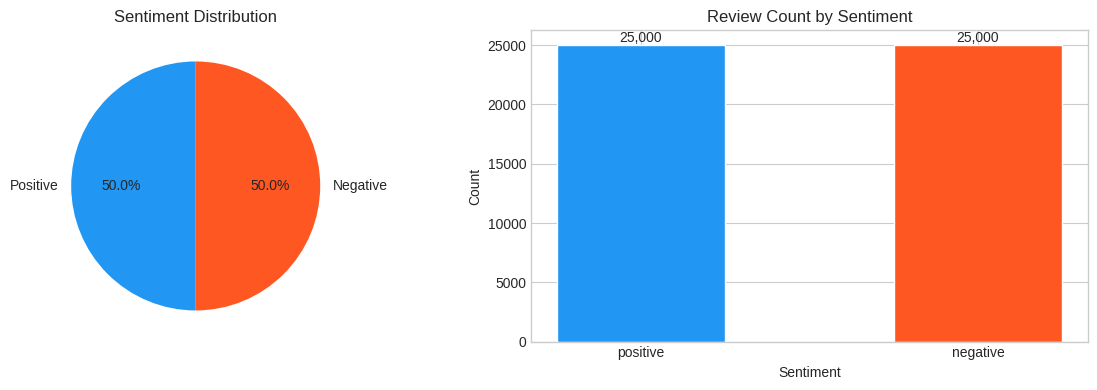

In [24]:
print(df['sentiment'].value_counts())
print(f"\nBalance: {df['sentiment'].value_counts(normalize=True).mul(100).round(1).to_dict()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# pie chart shows proportion at a glance
df['sentiment'].value_counts().plot(
    kind='pie', ax=axes[0],
    autopct='%1.1f%%',
    colors=['#2196F3', '#FF5722'],
    startangle=90,
    labels=['Positive', 'Negative']
)
axes[0].set_title('Sentiment Distribution')
axes[0].set_ylabel('')

# bar chart shows absolute counts with labels
counts = df['sentiment'].value_counts()
bars = axes[1].bar(
    counts.index, counts.values,
    color=['#2196F3', '#FF5722'], width=0.5, edgecolor='white'
)
axes[1].set_title('Review Count by Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
for bar in bars:
    axes[1].annotate(
        f'{int(bar.get_height()):,}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center', va='bottom'
    )

plt.tight_layout()
plt.show()

Word Count Statistics by Sentiment:
             count   mean    std   min    25%    50%    75%     max
sentiment                                                          
negative   25000.0  229.5  164.9   4.0  128.0  174.0  278.0  1522.0
positive   25000.0  232.8  177.5  10.0  125.0  172.0  284.0  2470.0


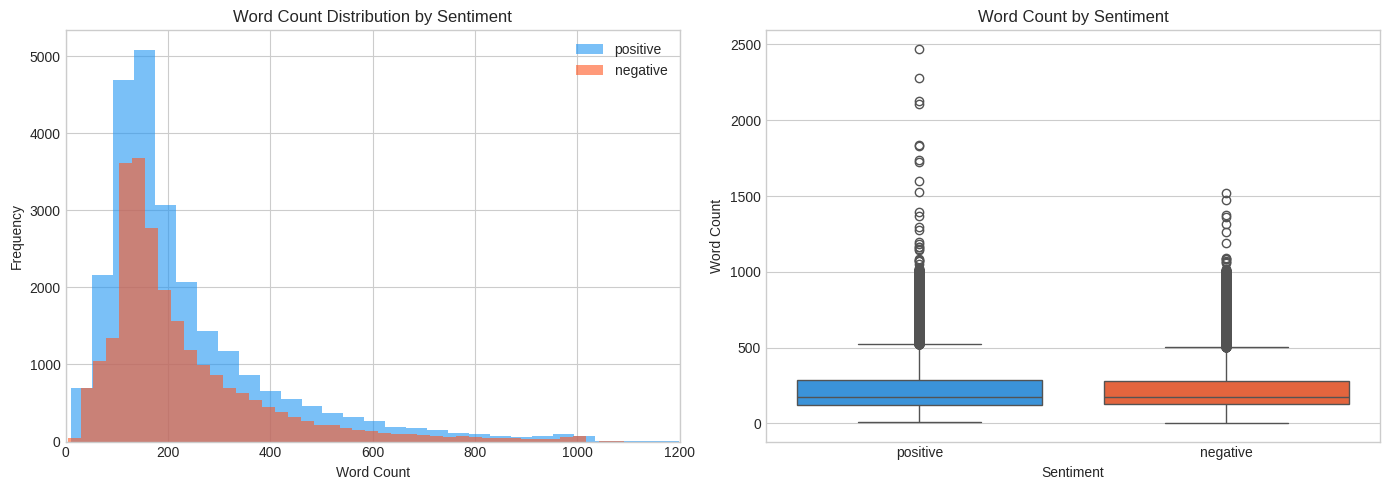

In [25]:
# rough word count by splitting on whitespace — good enough before cleaning
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

print('Word Count Statistics by Sentiment:')
print(df.groupby('sentiment')['word_count'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# overlay both classes to compare distributions
for sentiment, color in [('positive', '#2196F3'), ('negative', '#FF5722')]:
    axes[0].hist(
        df[df['sentiment'] == sentiment]['word_count'],
        bins=60, alpha=0.6, label=sentiment, color=color
    )
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Word Count Distribution by Sentiment')
axes[0].legend()
axes[0].set_xlim(0, 1200)  # clip long-tail outliers for readability

sns.boxplot(
    data=df, x='sentiment', y='word_count',
    palette={'positive': '#2196F3', 'negative': '#FF5722'},
    ax=axes[1]
)
axes[1].set_title('Word Count by Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.show()

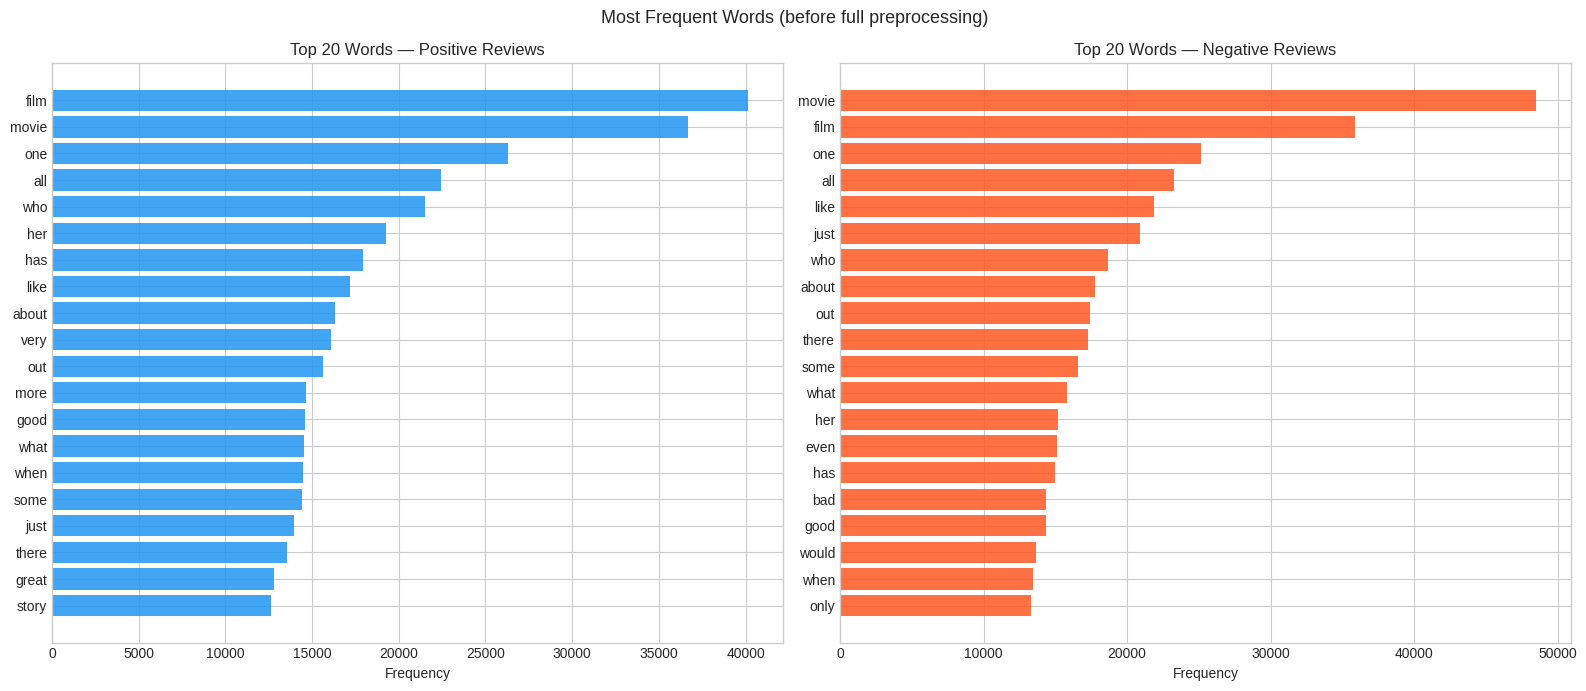

In [26]:
# minimal stopword list just for this EDA plot — not used in model training
BASIC_STOPS = {
    'the','a','and','of','to','is','in','it','this','that','was','br',
    'with','as','for','his','are','on','be','have','an','at','by','from',
    'he','she','they','we','you','i','or','but','not','so','its','their'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, (sentiment, color) in enumerate([('positive', '#2196F3'), ('negative', '#FF5722')]):
    # join all reviews for this class into one string for counting
    raw = ' '.join(df[df['sentiment'] == sentiment]['review'].str.lower())
    raw = re.sub(r'<[^>]+>', ' ', raw)   # strip HTML tags
    raw = re.sub(r'[^a-z\s]', '', raw)   # letters only
    words = Counter(w for w in raw.split() if w not in BASIC_STOPS and len(w) > 2)
    top   = pd.DataFrame(words.most_common(20), columns=['word', 'count'])
    axes[idx].barh(top['word'], top['count'], color=color, alpha=0.85)
    axes[idx].set_title(f'Top 20 Words — {sentiment.capitalize()} Reviews')
    axes[idx].set_xlabel('Frequency')
    axes[idx].invert_yaxis()  # highest count at the top

plt.suptitle('Most Frequent Words (before full preprocessing)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Text Preprocessing

The raw reviews contain HTML tags, punctuation, numbers, and common words that do not carry sentiment information. These are removed to keep only meaningful content.

Negation words like "not" and "never" are intentionally kept out of the stopword list. Removing them would flip the meaning of phrases like "not good" or "never disappoints".

In [27]:
STOP_WORDS = set(stopwords.words('english'))

# negations flip sentiment — removing 'not' would turn 'not good' into 'good'
NEGATIONS = {
    'no', 'not', 'nor', 'never', 'neither',
    'didn', 'don', 'doesn', 'won', 'wouldn',
    'can', 'cannot', 'isn', 'wasn', 'weren',
    'haven', 'hadn', 'shouldn'
}
STOP_WORDS -= NEGATIONS


def clean_text(text):
    text = re.sub(r'<[^>]+>', ' ', text)        # remove HTML tags
    text = text.lower()                          # normalize case
    text = re.sub(r'http\S+|www\S+', '', text) # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)       # keep letters only
    text = re.sub(r'\s+', ' ', text).strip()    # collapse extra whitespace
    tokens = [w for w in text.split() if w not in STOP_WORDS and len(w) > 2]
    return ' '.join(tokens)


sample = df['review'].iloc[0]
print('ORIGINAL (first 400 chars):')
print(sample[:400])
print('\nCLEANED (first 400 chars):')
print(clean_text(sample)[:400])

ORIGINAL (first 400 chars):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to

CLEANED (first 400 chars):
one reviewers mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scenes violence set right word trust not show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use word called nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inward


In [28]:
print('Cleaning 50,000 reviews...')
t0 = time()
df['cleaned_review'] = df['review'].apply(clean_text)
print(f'Done in {time() - t0:.1f}s')

# compare average length before and after to confirm cleaning had an effect
df['cleaned_word_count'] = df['cleaned_review'].apply(lambda x: len(x.split()))
print(f'\nAvg word count before cleaning: {df["word_count"].mean():.0f}')
print(f'Avg word count after  cleaning: {df["cleaned_word_count"].mean():.0f}')

Cleaning 50,000 reviews...
Done in 7.5s

Avg word count before cleaning: 231
Avg word count after  cleaning: 120


## 5. Feature Extraction — TF-IDF

TF-IDF converts text into numeric vectors. Words that appear often in one review but rarely across the full dataset get higher scores, making them more informative for classification.

Bigrams (two-word pairs like "not good" or "really bad") are included alongside unigrams because they carry more context. `sublinear_tf=True` applies log-scaling to term frequencies, which reduces the weight of very common words.

In [29]:
# encode labels: 1 = positive, 0 = negative
df['label'] = (df['sentiment'] == 'positive').astype(int)

X = df['cleaned_review']
y = df['label']

# stratify ensures the 50/50 class balance is preserved in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {len(X_train):,} samples')
print(f'Test  : {len(X_test):,}  samples')
print(f'Positive ratio (train): {y_train.mean():.3f}')
print(f'Positive ratio (test):  {y_test.mean():.3f}')

tfidf = TfidfVectorizer(
    max_features=50_000,   # keep the top 50k most informative tokens
    ngram_range=(1, 2),    # unigrams and bigrams
    sublinear_tf=True,     # apply log(1 + tf) to dampen very frequent terms
    min_df=2,              # drop tokens that appear in only one document
    strip_accents='unicode',
    analyzer='word'
)

# fit only on training data to prevent data leakage into the test set
t0 = time()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print(f'\nVectorization done in {time() - t0:.1f}s')
print(f'Feature matrix (train): {X_train_tfidf.shape}')
print(f'Feature matrix (test) : {X_test_tfidf.shape}')

Train : 40,000 samples
Test  : 10,000  samples
Positive ratio (train): 0.500
Positive ratio (test):  0.500

Vectorization done in 19.3s
Feature matrix (train): (40000, 50000)
Feature matrix (test) : (10000, 50000)


## 6. Model Training and Evaluation

Four models are trained on the same TF-IDF features. Each is evaluated with accuracy, precision, recall, F1-score, a confusion matrix, and a full classification report.

In [30]:
results        = {}   # stores metrics for all models
trained_models = {}   # stores fitted model objects for later use


def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    # train and time
    t0 = time()
    model.fit(X_tr, y_tr)
    train_time = time() - t0

    y_pred = model.predict(X_te)

    metrics = {
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall'   : recall_score(y_te, y_pred),
        'F1 Score' : f1_score(y_te, y_pred)
    }
    results[name]        = metrics
    trained_models[name] = model

    sep = chr(9472) * 52
    print(f'\n{sep}')
    print(f'  {name}  (trained in {train_time:.1f}s)')
    print(sep)
    for k, v in metrics.items():
        print(f'  {k:<12}: {v:.4f}')

    # confusion matrix — rows are actual, columns are predicted
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Negative', 'Positive'],
        yticklabels=['Negative', 'Positive']
    )
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    print('\nClassification Report:')
    print(classification_report(y_te, y_pred, target_names=['Negative', 'Positive']))


────────────────────────────────────────────────────
  Logistic Regression  (trained in 1.6s)
────────────────────────────────────────────────────
  Accuracy    : 0.9076
  Precision   : 0.9010
  Recall      : 0.9158
  F1 Score    : 0.9084


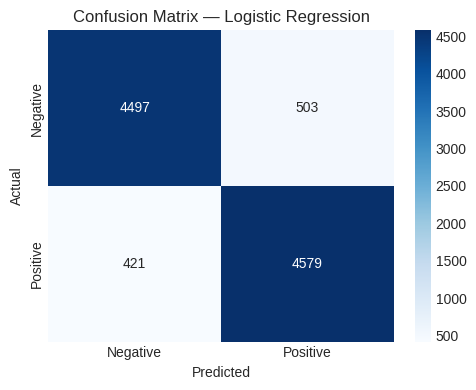


Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.90      0.91      5000
    Positive       0.90      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [31]:
# lbfgs is efficient for dense/sparse problems; C=1.0 works well without tuning
lr = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42)
evaluate_model('Logistic Regression', lr,
               X_train_tfidf, y_train, X_test_tfidf, y_test)


────────────────────────────────────────────────────
  Multinomial Naive Bayes  (trained in 0.0s)
────────────────────────────────────────────────────
  Accuracy    : 0.8835
  Precision   : 0.8778
  Recall      : 0.8910
  F1 Score    : 0.8844


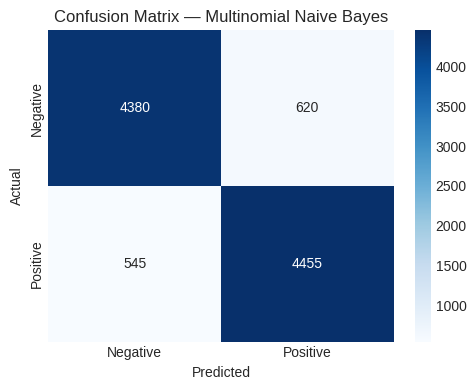


Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88      5000
    Positive       0.88      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [32]:
# alpha=0.1 gives lighter smoothing than the default 1.0 — works better here
nb = MultinomialNB(alpha=0.1)
evaluate_model('Multinomial Naive Bayes', nb,
               X_train_tfidf, y_train, X_test_tfidf, y_test)


────────────────────────────────────────────────────
  Linear SVM  (trained in 0.6s)
────────────────────────────────────────────────────
  Accuracy    : 0.9132
  Precision   : 0.9102
  Recall      : 0.9168
  F1 Score    : 0.9135


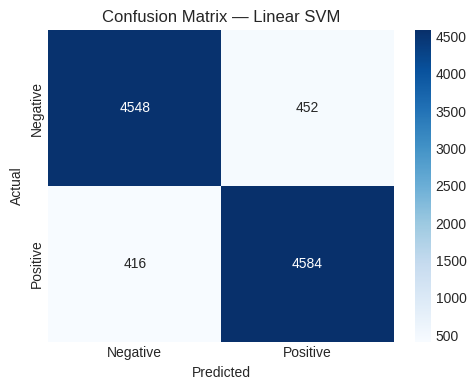


Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.91      0.91      5000
    Positive       0.91      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [33]:
# LinearSVC is much faster than SVC(kernel='linear') on large sparse matrices
svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
evaluate_model('Linear SVM', svm,
               X_train_tfidf, y_train, X_test_tfidf, y_test)


────────────────────────────────────────────────────
  Random Forest  (trained in 48.2s)
────────────────────────────────────────────────────
  Accuracy    : 0.8697
  Precision   : 0.8723
  Recall      : 0.8662
  F1 Score    : 0.8692


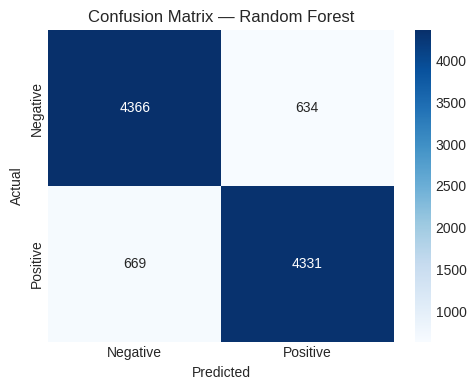


Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.87      0.87      5000
    Positive       0.87      0.87      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [34]:
# Random Forest is slower on sparse TF-IDF matrices — takes a few minutes on CPU
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
evaluate_model('Random Forest', rf,
               X_train_tfidf, y_train, X_test_tfidf, y_test)

## 7. Model Comparison

All four models are placed side by side using a summary table and visualizations to identify the best-performing one.

In [35]:
# build a summary DataFrame and sort by F1 to find the best model
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('F1 Score', ascending=False)

print('Model Performance Summary (sorted by F1 Score)')
print('=' * 58)
print(results_df.to_string())

best_model_name = results_df.index[0]
best_f1         = results_df.loc[best_model_name, 'F1 Score']
print(f'\nBest model: {best_model_name}  (F1 = {best_f1:.4f})')

Model Performance Summary (sorted by F1 Score)
                         Accuracy  Precision  Recall  F1 Score
Linear SVM                 0.9132     0.9102  0.9168    0.9135
Logistic Regression        0.9076     0.9010  0.9158    0.9084
Multinomial Naive Bayes    0.8835     0.8778  0.8910    0.8844
Random Forest              0.8697     0.8723  0.8662    0.8692

Best model: Linear SVM  (F1 = 0.9135)


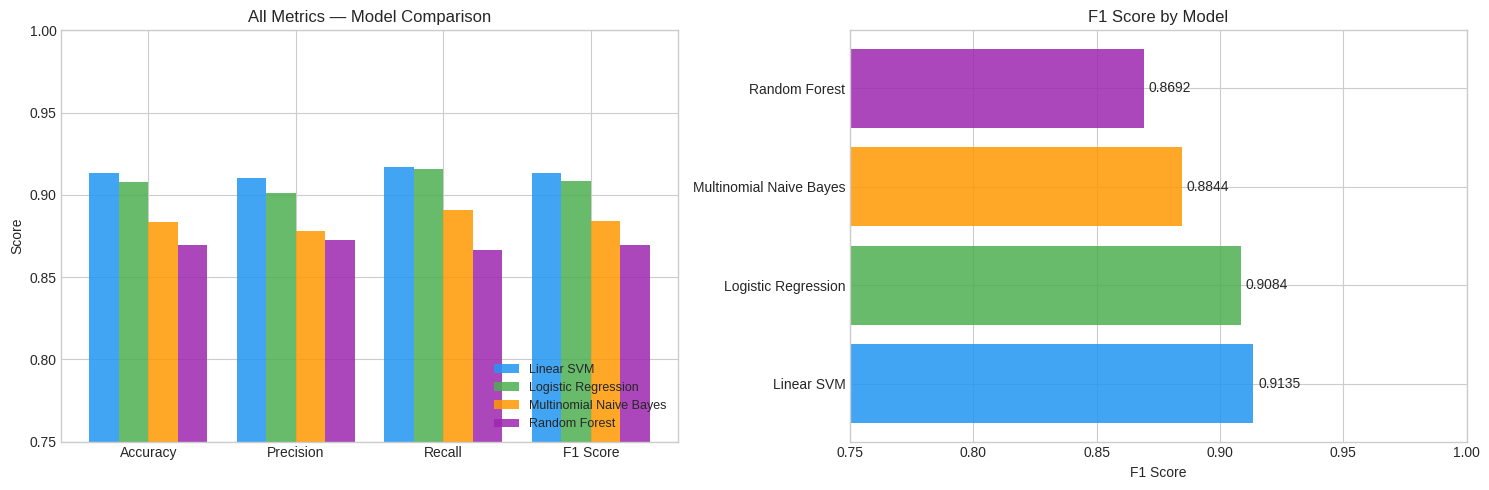

In [36]:
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names  = results_df.index.tolist()
palette      = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x     = np.arange(len(metrics_list))
width = 0.2  # width of each individual bar

for i, (name, color) in enumerate(zip(model_names, palette)):
    axes[0].bar(
        x + i * width,
        [results[name][m] for m in metrics_list],
        width, label=name, color=color, alpha=0.85
    )
# center tick labels under each group of bars
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics_list)
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics — Model Comparison')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].set_ylim(0.75, 1.0)

# horizontal bar makes model ranking easy to read
bars = axes[1].barh(
    model_names, results_df['F1 Score'],
    color=palette[:len(model_names)], alpha=0.85
)
axes[1].set_xlabel('F1 Score')
axes[1].set_title('F1 Score by Model')
axes[1].set_xlim(0.75, 1.0)

# add score labels at the end of each bar
for bar, val in zip(bars, results_df['F1 Score']):
    axes[1].text(
        val + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}', va='center', fontsize=10
    )

plt.tight_layout()
plt.show()

## 8. Error Analysis

A closer look at the reviews the best model gets wrong — false positives and false negatives. Some of these are genuinely ambiguous and would be difficult to label correctly even manually.

Total test samples  : 10,000
Correct predictions : 9,132  (91.32%)
Misclassified       : 868   (8.68%)
False Positives     : 452
False Negatives     : 416


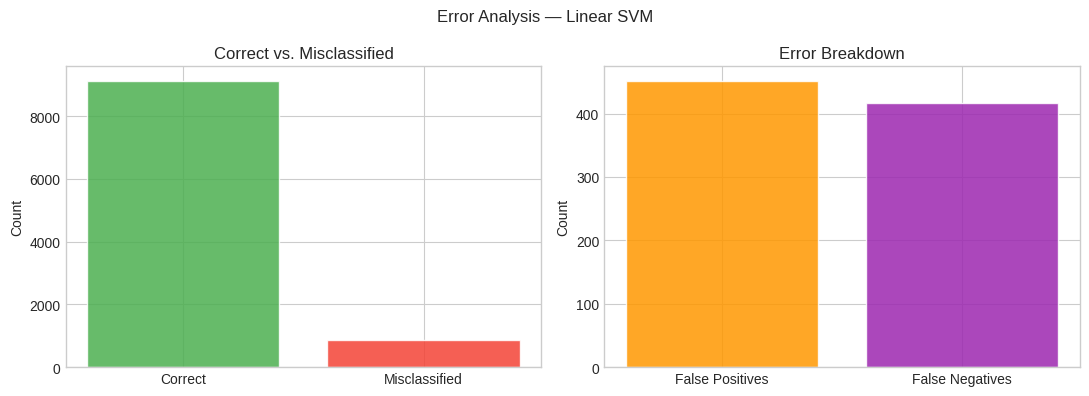

In [37]:
best_model   = trained_models[best_model_name]
y_pred_best  = best_model.predict(X_test_tfidf)

# reset index so boolean masks align correctly across all three Series
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
y_pred_s     = pd.Series(y_pred_best)

error_mask = y_pred_s != y_test_reset                  # all wrong predictions
fp_mask    = (y_pred_s == 1) & (y_test_reset == 0)    # predicted positive, actually negative
fn_mask    = (y_pred_s == 0) & (y_test_reset == 1)    # predicted negative, actually positive

print(f'Total test samples  : {len(y_test_reset):,}')
print(f'Correct predictions : {(~error_mask).sum():,}  ({(~error_mask).mean()*100:.2f}%)')
print(f'Misclassified       : {error_mask.sum():,}   ({error_mask.mean()*100:.2f}%)')
print(f'False Positives     : {fp_mask.sum():,}')
print(f'False Negatives     : {fn_mask.sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['Correct', 'Misclassified'],
            [(~error_mask).sum(), error_mask.sum()],
            color=['#4CAF50', '#F44336'], alpha=0.85, edgecolor='white')
axes[0].set_title('Correct vs. Misclassified')
axes[0].set_ylabel('Count')

axes[1].bar(['False Positives', 'False Negatives'],
            [fp_mask.sum(), fn_mask.sum()],
            color=['#FF9800', '#9C27B0'], alpha=0.85, edgecolor='white')
axes[1].set_title('Error Breakdown')
axes[1].set_ylabel('Count')

plt.suptitle(f'Error Analysis — {best_model_name}', fontsize=12)
plt.tight_layout()
plt.show()

In [38]:
print('Sample False Positives (predicted Positive, actually Negative):')
print('=' * 65)
fp_reviews = X_test_reset[fp_mask].reset_index(drop=True)
for i in range(min(3, len(fp_reviews))):
    print(f'\n[{i+1}] {fp_reviews[i][:350]}')
    print('-' * 65)

print('\nSample False Negatives (predicted Negative, actually Positive):')
print('=' * 65)
fn_reviews = X_test_reset[fn_mask].reset_index(drop=True)
for i in range(min(3, len(fn_reviews))):
    print(f'\n[{i+1}] {fn_reviews[i][:350]}')
    print('-' * 65)

Sample False Positives (predicted Positive, actually Negative):

[1] yes mtv really way market daria started clever teenage angst comment everything sucks make viewer feel better sucky teenage life sitcom mutated deal problems charade used watch daria time loved sitting watching called movie can wonder point daria tells lead life college excuse didn point daria made every episode like long matter rest sick sad world
-----------------------------------------------------------------

[2] little quentin seems mastered art cake eating usual pure sadistic display can explained clever thought provoking way sending violence back audience face sure tarantino violence baaad sadism baaad well worth wading make point brilliant juvenile part audience may well not clever enough follow smart references higher levels consciousness though confid
-----------------------------------------------------------------

[3] film listed made not film available something weird video driver scare films vol one th

## 9. Save Best Model

The best-performing model and TF-IDF vectorizer are saved with Joblib for later use without retraining. A metadata JSON file records the model name and test metrics.

In [39]:
os.makedirs('models/v1', exist_ok=True)

joblib.dump(best_model, 'models/v1/best_model.pkl')
joblib.dump(tfidf,      'models/v1/tfidf_vectorizer.pkl')

# save model name and scores so we know what was trained without re-running
metadata = {
    'best_model'  : best_model_name,
    'test_metrics': {k: round(float(v), 4) for k, v in results[best_model_name].items()},
    'tfidf_config': {
        'max_features': 50000,
        'ngram_range' : [1, 2],
        'sublinear_tf': True,
        'min_df'      : 2
    },
    'train_size': int(len(X_train)),
    'test_size' : int(len(X_test))
}

with open('models/v1/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Best model  : {best_model_name}')
print(f'F1 Score    : {results[best_model_name]["F1 Score"]:.4f}')
print('Saved: models/v1/best_model.pkl')
print('Saved: models/v1/tfidf_vectorizer.pkl')
print('Saved: models/v1/metadata.json')

Best model  : Linear SVM
F1 Score    : 0.9135
Saved: models/v1/best_model.pkl
Saved: models/v1/tfidf_vectorizer.pkl
Saved: models/v1/metadata.json


## 10. Custom Review Testing

The model is tested on a few hand-written reviews to check how well it generalizes to text it has never seen before.

In [40]:
def predict_sentiment(review, model, vectorizer, verbose=True):
    cleaned  = clean_text(review)              # apply the same cleaning used during training
    features = vectorizer.transform([cleaned]) # convert to TF-IDF vector
    pred     = model.predict(features)[0]
    label    = 'Positive' if pred == 1 else 'Negative'
    if verbose:
        print(f'Review    : {review[:90]}...')
        print(f'Sentiment : {label}')
        print('-' * 60)
    return label

In [41]:
test_reviews = [
    'This movie was absolutely fantastic. The acting was superb and the story kept me hooked throughout.',
    'Complete waste of time. Terrible acting, the plot made no sense, and the ending was painfully bad.',
    'It was okay. Not great, not terrible. Some scenes were interesting but it dragged quite a bit.',
    'I had really high hopes but the film let me down. Poorly directed and the dialogue felt forced.',
    'One of the best films I have seen this year. Brilliant performances and a genuinely moving story.',
    'A total mess from start to finish. Avoid this one.',
    'Not sure how I feel about it. It has real strengths but also some glaring problems.'
]

print(f'Testing {best_model_name} on custom reviews')
print('=' * 60)
for review in test_reviews:
    predict_sentiment(review, best_model, tfidf)

Testing Linear SVM on custom reviews
Review    : This movie was absolutely fantastic. The acting was superb and the story kept me hooked th...
Sentiment : Positive
------------------------------------------------------------
Review    : Complete waste of time. Terrible acting, the plot made no sense, and the ending was painfu...
Sentiment : Negative
------------------------------------------------------------
Review    : It was okay. Not great, not terrible. Some scenes were interesting but it dragged quite a ...
Sentiment : Negative
------------------------------------------------------------
Review    : I had really high hopes but the film let me down. Poorly directed and the dialogue felt fo...
Sentiment : Negative
------------------------------------------------------------
Review    : One of the best films I have seen this year. Brilliant performances and a genuinely moving...
Sentiment : Positive
------------------------------------------------------------
Review    : A total mes

## 11. Export Models

The trained model and vectorizer are zipped into `models.zip` for download.
After running the cell below, go to the Kaggle output panel on the right side and download the file from there.


In [42]:
import shutil
from IPython.display import FileLink

# zip the entire models folder
shutil.make_archive('models_v1_export', 'zip', 'models', 'v1')

print("models_v1_export.zip is ready.")
print("Download it from the Kaggle output panel (right side > Output tab).")

# clickable download link (works in Kaggle and local Jupyter)
FileLink('models_v1_export.zip')


models_v1_export.zip is ready.
Download it from the Kaggle output panel (right side > Output tab).


/kaggle/working/models_v1_export.zip